In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal
from langchain_ollama import ChatOllama
from pydantic import BaseModel,Field

In [2]:
llm = ChatOllama(
    base_url="http://localhost:11434",
    model = "llama3.2",
    temperature="0.7"
)

In [3]:
class SentimentSchema(BaseModel):
    sentiment: Literal["Positive", "Negative"] = Field(description="Sentiment of the review")

In [4]:
structured_model = llm.with_structured_output(SentimentSchema)

In [5]:
class SRState(TypedDict):
    review: str

    sentiment: Literal["Positive", "Negative"]
    diagnosis: dict
    response: str

In [6]:
graph = StateGraph(SRState)

In [7]:
def find_sentiment(state: SRState):
    review = state['review']
    prompt = f"Find the sentiment of this review: {review}"
    sentiment = structured_model.invoke(prompt).sentiment
    return {'sentiment': sentiment}

def run_diagnosis(state: SRState):
    review = state['review']
    prompt = f"Find the tone, reason, urgency from this {review}"
    diagnosis = llm.invoke(prompt).content
    return {"diagnosis" : diagnosis}


def positive_response(state: SRState):
    review = state['review']
    prompt= f"write a positive thank you feedback for this review : {review} of the user"
    result = llm.invoke(prompt).content
    return {'response': result}

def negative_response(state: SRState):
    review = state['review']
    diagnosis = state['diagnosis']
    prompt= f"I am giving you the users review and the diagnosis of the review, and your task is to generate a response based on this. review: {review}, diagnosis : {diagnosis} "
    result = llm.invoke(prompt).content
    return {'response': result}

def select_branch(state: SRState) -> Literal["positive_response","run_diagnosis"]:
    sentiment = state['sentiment']
    if sentiment.lower() == "positive":
        return "positive_response"
    elif sentiment.lower() == "negative": 
        return "run_diagnosis"


In [8]:
graph.add_node("find_sentiment", find_sentiment)
graph.add_node("run_diagnosis", run_diagnosis)
graph.add_node("positive_response", positive_response)
graph.add_node("negative_response", negative_response)


In [9]:
graph.add_edge(START, "find_sentiment")

graph.add_conditional_edges("find_sentiment", select_branch)

graph.add_edge("run_diagnosis","negative_response")
graph.add_edge("negative_response", END)
graph.add_edge("positive_response", END)



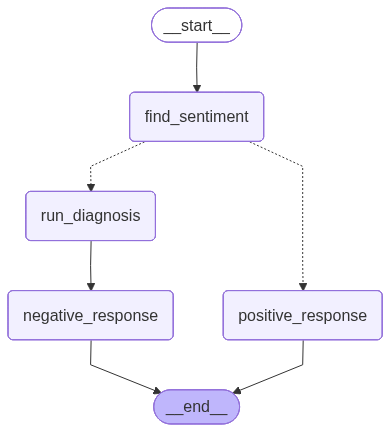

In [10]:
workflow = graph.compile()
workflow

In [11]:
initial_state = {
    'review': "I’ve been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality."
}

final_state = workflow.invoke(initial_state)

In [12]:
print(final_state)

{'review': 'I’ve been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality.', 'sentiment': 'Negative', 'diagnosis': 'Based on the text, here\'s what can be inferred about the tone, reason, and urgency:\n\n**Tone:**\n\n* Frustrated: The use of words like "over an hour now" and "unacceptable" convey a sense of frustration and annoyance.\n* Disappointed: The fact that the app\'s freezing issue has prevented the user from logging in suggests disappointment with the app\'s performance.\n\n**Reason:**\n\n* Technical issue: The text implies that there is a technical problem with the app, specifically with the authentication screen, which is causing the freezing issue.\n* Bug: The use of the phrase "this kind of bug is unacceptable" suggests that the user has encountered a known issue with the app, and they are expressing their d

In [13]:
print(final_state['review'])

I’ve been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality.


In [14]:
print(final_state['sentiment'])

Negative


In [15]:
print(final_state['diagnosis'])

Based on the text, here's what can be inferred about the tone, reason, and urgency:

**Tone:**

* Frustrated: The use of words like "over an hour now" and "unacceptable" convey a sense of frustration and annoyance.
* Disappointed: The fact that the app's freezing issue has prevented the user from logging in suggests disappointment with the app's performance.

**Reason:**

* Technical issue: The text implies that there is a technical problem with the app, specifically with the authentication screen, which is causing the freezing issue.
* Bug: The use of the phrase "this kind of bug is unacceptable" suggests that the user has encountered a known issue with the app, and they are expressing their disappointment with the fact that it persists despite reinstalling the app.

**Urgency:**

* High: The text implies that the user needs to log in urgently, as evidenced by the phrase "over an hour now". This suggests that the user is under pressure to access the app's functionality, and the freezi

In [16]:
print(final_state['response'])

Here's a potential response based on the review and diagnosis:

Dear [User],

We apologize for the frustration and inconvenience caused by the app freezing on the authentication screen. We understand how important it is to have access to our app, especially when you're trying to log in for an extended period.

We're taking immediate action to resolve this issue. Our development team has been notified, and we're working to reproduce the bug to identify the root cause. In the meantime, we'll provide a temporary workaround or a fix as soon as possible.

In the future, we'll prioritize fixing technical issues like this one, especially when they affect basic functionality. We appreciate your patience and understanding as we work to resolve this issue.

If you're experiencing any further issues, please don't hesitate to reach out to us directly at [support email or phone number]. We're here to help.

Thank you for pointing out this bug, which will help us improve our app's stability and perf

In [17]:
initial_state2 = {"review":"""I don’t understand how an app can still have such basic issues. Every time I try to upload something, it just crashes midway. I’ve cleared cache, restarted my phone—nothing works. This is incredibly frustrating."""}
final_state2 = workflow.invoke(initial_state2)

print(final_state2['review'])
print("*" * 20)
print(final_state2['sentiment'])
print("*" * 20)
print(final_state2['diagnosis'])
print("*" * 20)
print(final_state2['response'])

I don’t understand how an app can still have such basic issues. Every time I try to upload something, it just crashes midway. I’ve cleared cache, restarted my phone—nothing works. This is incredibly frustrating.
********************
Negative
********************
Here's a breakdown of the tone, reason, and urgency in the given text:

**Tone:**

* Frustrated: The use of the word "incredibly" to describe the frustration level conveys a strong sense of annoyance.
* Disappointed: The speaker seems disappointed that an app with basic issues is still available for use.
* Angry: The tone is slightly angry, as evidenced by the phrase "This is incredibly frustrating," which implies that the speaker feels strongly about the problem.

**Reason:**

* Technical issue: The reason for the frustration is a technical issue with the app, specifically its inability to upload content without crashing.
* Inability to resolve the issue: The speaker has tried clearing cache and restarting their phone, but not

In [18]:
initial_state3 = {"review":"""The latest update made things worse instead of better. Features that used to work smoothly are now laggy and unresponsive. It feels like no proper testing was done before release."""}
final_state3 = workflow.invoke(initial_state3)

print(final_state3['review'])
print("*" * 20)
print(final_state3['sentiment'])
print("*" * 20)
print(final_state3['diagnosis'])
print("*" * 20)
print(final_state3['response'])

The latest update made things worse instead of better. Features that used to work smoothly are now laggy and unresponsive. It feels like no proper testing was done before release.
********************
Negative
********************
Here's an analysis of the tone, reason, and urgency in the given text:

**Tone:**
The tone is negative, critical, and disappointed. The user expresses frustration with the latest update, which they feel has caused problems rather than resolving them.

**Reason:**
The reason for the negative experience appears to be a lack of proper testing before release. The user suggests that the developers may not have thoroughly tested their features before launching an update, leading to issues such as laggy and unresponsive behavior.

**Urgency:**
There is a sense of urgency in the text, but it's more constructive than confrontational. The user seems to be urging the developers to address the problems with the update, rather than demanding immediate action. However, the

In [21]:
initial_state4 = {"review":"""I keep getting logged out randomly, and when I try to sign back in, it just spins endlessly. For an app that’s supposed to be reliable, this is a huge disappointment."""}
final_state4 = workflow.invoke(initial_state4)

print(final_state4['review'])
print("*" * 20)
print(final_state4['sentiment'])
print("*" * 20)
print(final_state4['diagnosis'])
print("*" * 20)
print(final_state4['response'])

I keep getting logged out randomly, and when I try to sign back in, it just spins endlessly. For an app that’s supposed to be reliable, this is a huge disappointment.
********************
Negative
********************
Here's my analysis of the tone, reason, and urgency of the given text:

**Tone:**
The tone is negative and disappointed. The user is expressing frustration with the app's behavior, which is causing them inconvenience and distrust.

**Reason:**
The reason for the user's frustration appears to be a technical issue with the app's login functionality. Specifically, they are experiencing:

* Random logging out
* Infinite spinning when trying to sign back in

This suggests that there may be an underlying problem with the app's server-side or client-side implementation.

**Urgency:**
The urgency is moderate to high. The user is expressing frustration and disappointment, which implies a sense of importance and need for resolution. They also mention that this behavior is a "huge d

In [23]:
initial_state5 = {"review":"I’ve been using this app daily for weeks now, and it’s been a smooth experience overall. The interface is clean, and everything loads quickly. Definitely one of the better apps I’ve tried recently."}
final_state5 = workflow.invoke(initial_state5)

print(final_state5['review'])
print("*" * 50)
print(final_state5['sentiment'])
print("*" * 50)
print(final_state5['response'])

I’ve been using this app daily for weeks now, and it’s been a smooth experience overall. The interface is clean, and everything loads quickly. Definitely one of the better apps I’ve tried recently.
**************************************************
Positive
**************************************************
Here's a possible positive response to this review:

"Thank you so much for taking the time to share your feedback! We're thrilled to hear that our app has been meeting your needs and providing a smooth experience. We appreciate your kind words about our interface, and we're glad to know that it's made a difference in your daily use. We're constantly working to improve and refine our app, and feedback like yours helps us stay on track. Thank you for being one of our satisfied users - we're glad to have you!"


In [24]:
initial_state6 = {"review":"""Really impressed with how intuitive everything feels. Even as a first-time user, I was able to navigate without any confusion. Performance has been solid so far."""}
final_state6 = workflow.invoke(initial_state6)

print(final_state6['review'])
print("*" * 20)
print(final_state6['sentiment'])
print("*" * 20)
print(final_state6['response'])

Really impressed with how intuitive everything feels. Even as a first-time user, I was able to navigate without any confusion. Performance has been solid so far.
********************
Positive
********************
Here's a potential positive feedback response:

"Thank you so much for taking the time to share your experience with our product! We're thrilled to hear that you found everything intuitive and easy to use, even as a first-time user. It's great to know that we were able to make a smooth transition for you, and we're delighted that you've been impressed with the performance so far. Your kind words have made our day, and we're grateful for customers like you who help us continue to strive for excellence!"


In [25]:
initial_state7 = {"review":"""The recent update actually fixed a lot of the issues I was facing earlier. The app feels faster, and I haven’t experienced any crashes since. Great improvement!"""}
final_state7 = workflow.invoke(initial_state7)

print(final_state7['review'])
print("*" * 20)
print(final_state7['sentiment'])
print("*" * 20)
print(final_state7['response'])

The recent update actually fixed a lot of the issues I was facing earlier. The app feels faster, and I haven’t experienced any crashes since. Great improvement!
********************
Positive
********************
Here's a positive thank-you feedback:

"We're thrilled to hear that the recent update addressed the concerns you had with the app! Our team is glad to know that our efforts have resulted in improved performance, and we're grateful for your kind words about the app feeling faster. We appreciate your patience and understanding during this time, and we're even more committed to continuing to provide a seamless experience for all our users. Thank you again for taking the time to share your feedback - it's invaluable to us!"
